In [31]:
import numpy as np
from scipy.stats import norm, poisson, gamma, kurtosis, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

The Stochastic Volatility model we will implement is the Heston model that assumes GBM for the spot price, $S_t$, hence:

$dS_t = \mu S_t dt + \sqrt\nu_t S_t dW_t^S$, then the instantaneous variance follows FSR process:

$d\nu_t = \kappa (\theta - \nu_t) dt + \epsilon \sqrt\nu_t dW_t^{\nu}$. The two brownian motions increments are correlated with expectation $\rho dt$. Furthermore, the Feller condition must be satisfied where $\epsilon^2 \leq 2\kappa\theta$. Simulate this with Euler-Maruyama scheme. Let us show one possible path here.

Aside, if we want to model log-price we must use Ito and have ABM for $logS_t$ then we must exponentiate in results. 

In [32]:
# outline some params
nsteps = 10_000
dt = 1/252 
mu = 0.0 # zero drift
kappa = 2
theta = (0.25 **2)
epsilon = 0.15
rho = -0.7 # negative so captures leverage effect of volatility (only other is TGARCH)
v0 = (0.2 **2) 
S0 = 10 # all annualised paramas

In [5]:
def generate_heston_path(nsteps, dt, mu, kappa, theta, epsilon, rho, v0, S0):

    dW1 = norm.rvs(loc = 0, scale = 1, size = nsteps) * np.sqrt(dt)
    dW2 = norm.rvs(loc = 0, scale = 1, size = nsteps) * np.sqrt(dt)

    dWS = dW1
    dWv = rho * dW1 + np.sqrt(1 - rho**2) * dW2

    logS = np.zeros(nsteps)
    logS[0] = np.log(S0)
    v = np.zeros(nsteps)
    v[0] = v0
    r = np.zeros(nsteps-1) # the innovation only return we correct for Ito drift in log price update

    for i in range(1, nsteps):
        r[i-1] = np.sqrt(v[i-1]) * dWS[i-1]

        logS[i] = logS[i-1] + (mu - 0.5 * v[i-1]) * dt + r[i-1]

        v[i] = v[i-1] + kappa * (theta - v[i-1]) * dt + epsilon * np.sqrt( v[i-1]) * dWv[i-1]
        v[i] = max(0, v[i])

    S = np.exp(logS)

    return S, v, r

In [7]:
npaths = 500

S = np.zeros((nsteps, npaths))
v = np.zeros((nsteps, npaths))
r = np.zeros((nsteps-1, npaths))

for i in range(npaths):
    S[:, i], v[:, i], r[:, i] = generate_heston_path(nsteps, dt, mu, kappa, theta, epsilon, rho, v0, S0)

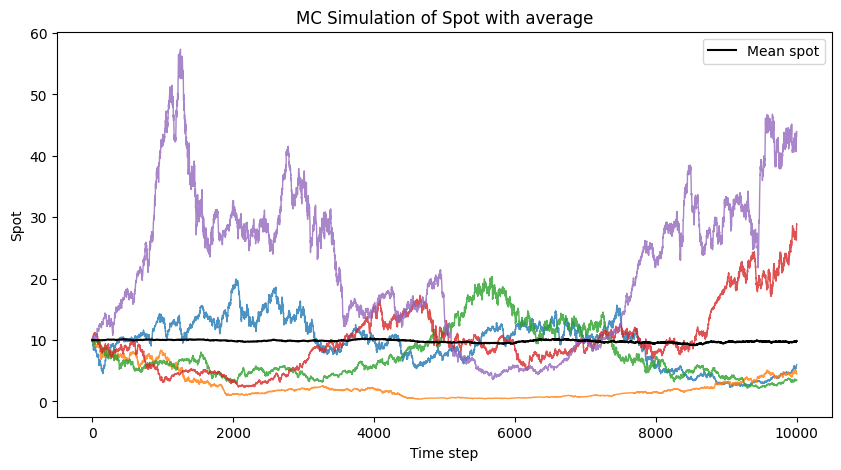

In [14]:
plt.figure(figsize=(10, 5))
for k in range(4, 9):
    plt.plot(S[:, k], linewidth = 1, alpha = 0.8)

mean_price = np.mean(S, axis = 1)
plt.plot(mean_price, "-k", label = "Mean spot")
plt.xlabel("Time step")
plt.ylabel("Spot")
plt.title("MC Simulation of Spot with average")
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_86656/634656356.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


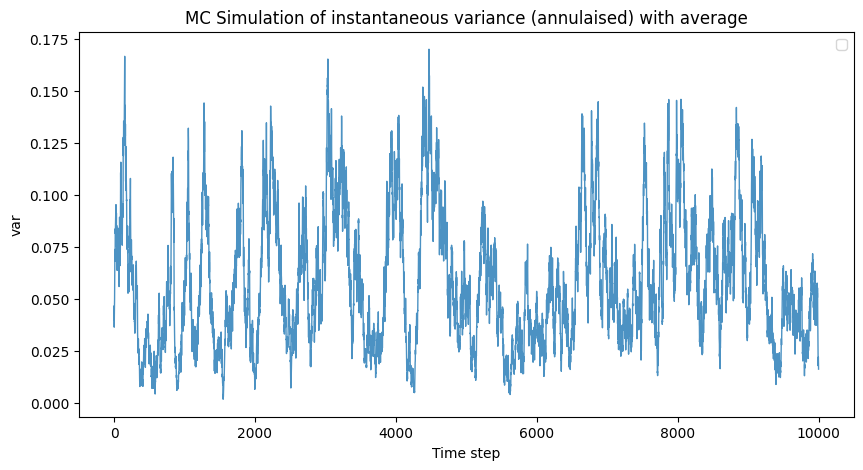

In [10]:
plt.figure(figsize=(10, 5))
for k in range(4, 5):
    plt.plot(v[:, k], linewidth = 1, alpha = 0.8)

plt.xlabel("Time step")
plt.ylabel("var")
plt.title("MC Simulation of instantaneous variance (annulaised) with average")
plt.legend()

## Jumps 1

The first jump process we can integrate into the Heston model is the Merton-Jump diffusion process. Consider keeping with the log price version so that the SDE becomes:

$dlogS_t = (\mu - 0.5 \nu_t^2) dt + \sqrt\nu_t dW_t^S + dJ$. 

J here is the jump component. We simulate the number of jumps in a time interval given by a Poisson distribution. Each jump follows a normal distribution that we sum up for the increment. If $dN \sim Poiss(\lambda \delta t)$ then $dJ = \mu_z dN + \sigma_z \sqrt(dN) \text{NORMRV}$.

Simulations not done under Q as we havent corrcted drift. Is this needed for option work later on?

In [33]:
def generate_heston_path_mj(nsteps, dt, mu, kappa, theta, epsilon, rho, v0, S0, lamb, mu_z, sigma_z):

    dW1 = norm.rvs(loc = 0, scale = 1, size = nsteps) * np.sqrt(dt)
    dW2 = norm.rvs(loc = 0, scale = 1, size = nsteps) * np.sqrt(dt)

    dWS = dW1
    dWv = rho * dW1 + np.sqrt(1 - rho**2) * dW2

    logS = np.zeros(nsteps)
    logS[0] = np.log(S0)
    v = np.zeros(nsteps)
    v[0] = v0
    r = np.zeros(nsteps-1) # ie log return innovations only (diffusion + jump innovations)

    for i in range(1, nsteps):
        dN = poisson.rvs(mu = lamb * dt)
        dJ = mu_z * dN + sigma_z * np.sqrt(dN) * norm.rvs()

        r[i-1] = np.sqrt(v[i-1]) * dWS[i-1] + dJ # only zero mean as mu_z is zero

        logS[i] = logS[i-1] + (mu - 0.5 * v[i-1]) * dt + r[i-1]
        v[i] = v[i-1] + kappa * (theta - v[i-1]) * dt + epsilon * np.sqrt(v[i-1]) * dWv[i-1]
        v[i] = max(0, v[i])

    S = np.exp(logS)

    return S, v, r


In [34]:
mu_z = 0.0 # asymmetry - negative so on average jumps negative
sigma_z = 0.15  # width of jumps
lamb = 0.5 # model parameters of the jump part (NCPP)  - affects number of jumps

In [35]:
npaths = 500

S = np.zeros((nsteps, npaths))
v = np.zeros((nsteps, npaths))
r = np.zeros((nsteps-1, npaths))

for i in range(npaths):
    S[:, i], v[:, i], r[:, i] = generate_heston_path_mj(nsteps, dt, mu, kappa, theta, epsilon, rho, v0, S0, lamb, mu_z, sigma_z)

In [36]:
np.savez("all_paths_heston_jumps.npz", r=r, h=v, S=S)

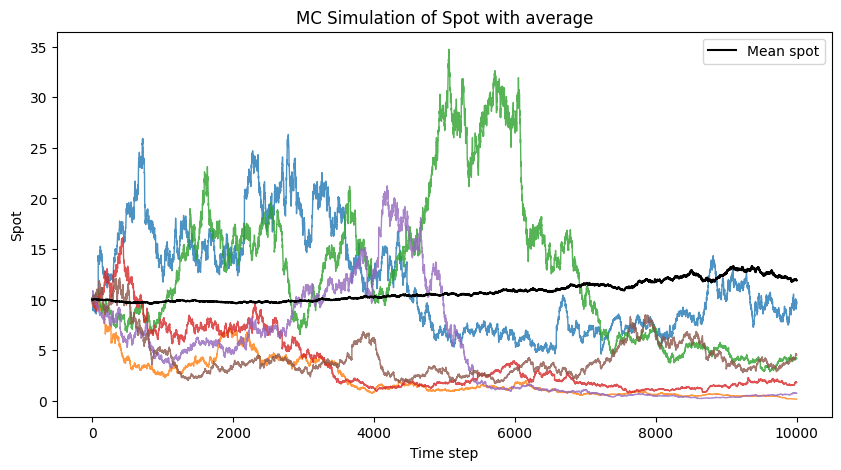

In [26]:
plt.figure(figsize=(10, 5))
for k in range(14, 20):
    plt.plot(S[:, k], linewidth = 1, alpha = 0.8)

mean_price = np.mean(S, axis = 1)
plt.plot(mean_price, "-k", label = "Mean spot")
plt.xlabel("Time step")
plt.ylabel("Spot")
plt.title("MC Simulation of Spot with average")
plt.legend()

Paths look like they go down a bit as we set no drift and the ito correction pushes it down a little bit.

# Let us do fat tails, clustering, long memory analysis on this MJD

In [8]:
def compute_acf(x, lags):
    x_mean = x.mean()
    y = x - x_mean

    acf_vals = np.zeros(lags)
    acf_vals[0] = 1.0
    for i in range(1, lags):

        acf_vals[i] = (np.dot(y[i:], y[:-i])) / np.dot(y, y)

    return acf_vals

def get_confd_bands(n_obs, acfs, alpha = 0.05):
    '''
    Assuming underlying process is MA(q) we use this.
    '''


    K = len(acfs)
    z = norm.ppf(1 - alpha/2)
    lower = np.zeros(K)
    upper = np.zeros(K)

    for h in range(1, K):
        var_h = (1 + 2*np.sum(acfs[1:h]**2)) / n_obs
        halfwidth = z * np.sqrt(var_h)
        lower[h] = -halfwidth
        upper[h] =  halfwidth

    return lower, upper

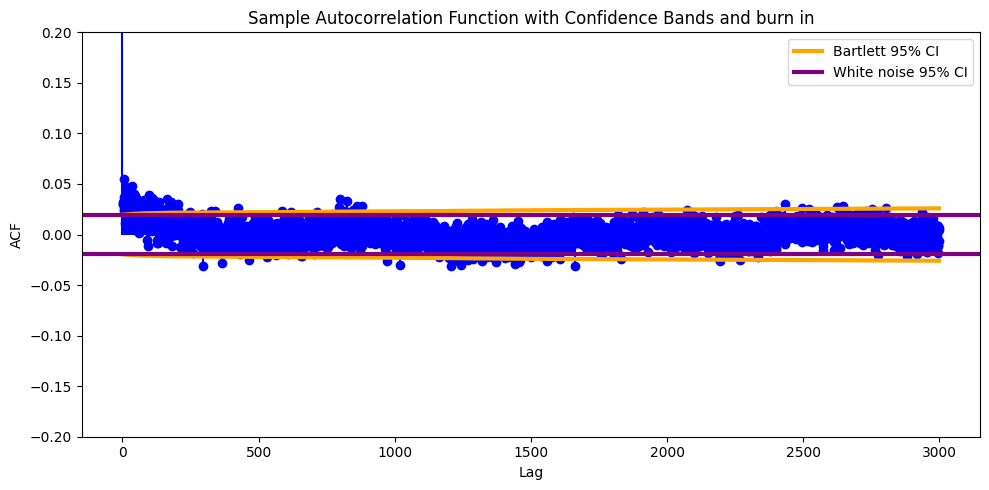

In [17]:
lags = 3000
x = abs(r[:, 4])
n_obs = len(x)

acf_vals = compute_acf(x, lags)
lo, up = get_confd_bands(n_obs, acf_vals)

other = 1.96 / np.sqrt(n_obs)

plt.figure(figsize=(10, 5))
plt.stem(range(0, lags), acf_vals[0:], linefmt='b-', markerfmt='bo', basefmt=' ')
plt.plot(up[1:], '-',color = 'orange', linewidth = 3,  label = "Bartlett 95% CI")
plt.plot(lo[1:], "-", color = "orange", linewidth = 3)
plt.axhline(y = other, color = "purple", linewidth = 3, label = "White noise 95% CI")
plt.axhline(y = -other, color = "purple", linewidth = 3)
plt.ylim([-0.2, 0.2])
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('Sample Autocorrelation Function with Confidence Bands and burn in')
plt.tight_layout()
plt.legend()
plt.show()


Clear vol clustering as well as some sort of long memory given especially large ACF values at very large lags.

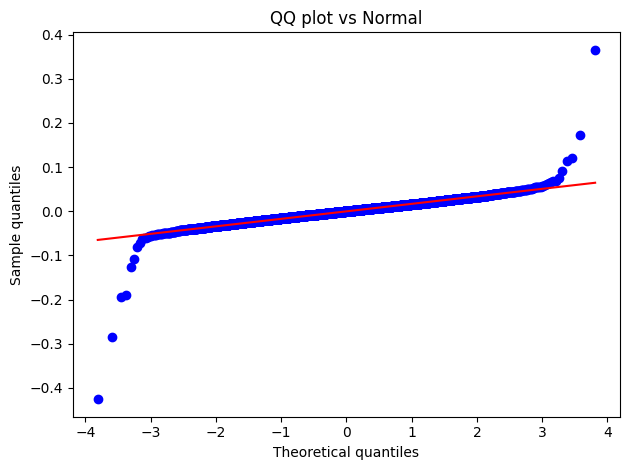

In [10]:
X = r[:, 5]  # leave burn in 

stats.probplot(X, dist="norm", plot=plt)
plt.title("QQ plot vs Normal")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Sample quantiles")
plt.tight_layout()
plt.show()

In [18]:
Exkurts = np.zeros(npaths)
for i in range(npaths):
    Exkurts[i] = kurtosis(r[:, i], fisher=True) 

print(f"Mean excess kurt over {npaths} paths: {Exkurts.mean()}")

Mean excess kurt over 500 paths: 33.594155521877816


In [30]:
# as mentioned vol clustering will present itself as autocorreltaions at short lags
lags = 10

ps = []

for i in range(npaths):

    res = acorr_ljungbox(abs(r[:, i]), lags = lags, return_df=True)
    ps.append(res['lb_pvalue'].iloc[-1])

print(f"Mean p-value of Ljung Box test: {np.mean(ps)}")

bonf_corr = 0.01 / npaths
print(f"Bonf Corr: {bonf_corr}")

Mean p-value of Ljung Box test: 0.0010017830401657826
Bonf Corr: 2e-05


In [29]:
fisher_p   = combine_pvalues(ps, method='fisher')[1]
fisher_p

np.float64(0.0)

In [19]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum

In [20]:
def get_hurst(data):
    '''
    Use my MF-DFA functions to get hurst exponent only.
    '''

    X = data
    N = len(X)
    s_min = 10
    s_max = len(X) // 4
    q = 2 # reccomended in lit for between -6 and 6
    m= 1
    steps = 40
    mu_X = np.mean(X)
    Y = np.cumsum(X - mu_X)

    F_q, ss, _, _, _ = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)

    H = get_generalised_hurst(F_q = F_q, ss = ss)

    return H


In [21]:
hursts_r = []
hursts_abs_r = []

for i in range(npaths):
    H_r = get_hurst(data = r[:, i])
    H_abs_r = get_hurst(data = abs(r[:, i]))
    hursts_r.append(H_r)
    hursts_abs_r.append(H_abs_r)              

In [22]:
print(f"Hurst average on returns: {np.mean(hursts_r)}")
print(f"Hurst average on absolute returns: {np.mean(hursts_abs_r)}")

Hurst average on returns: 0.49892927769250905
Hurst average on absolute returns: 0.6693215876316976


A very large amount of persistence in the model seen.

# MF-DFA

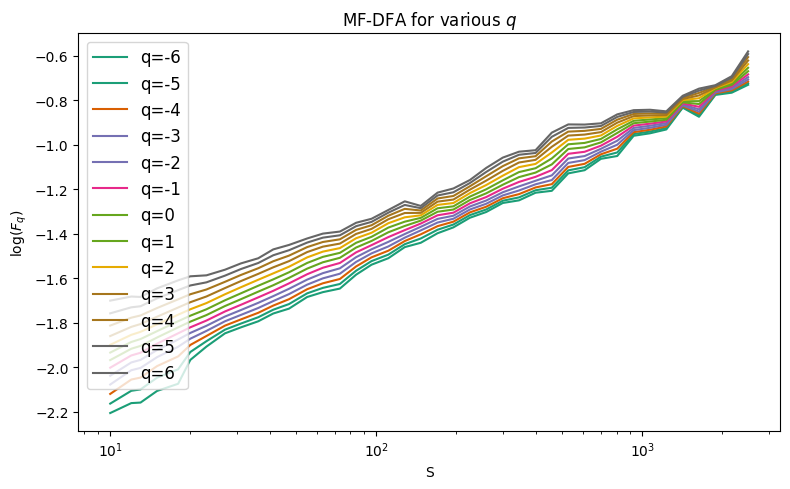

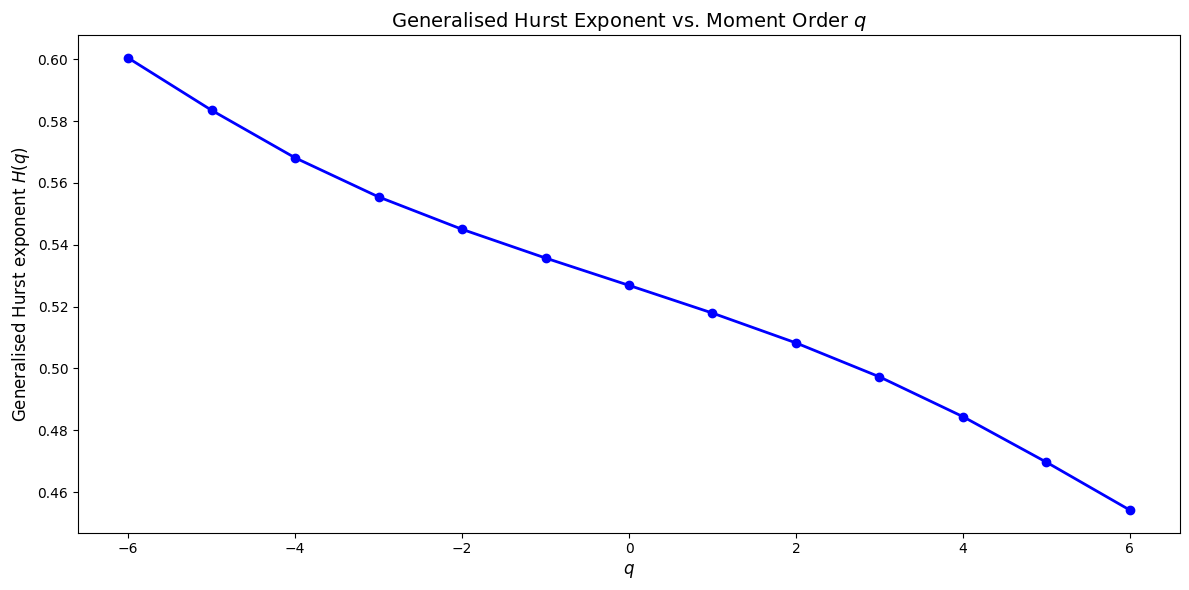

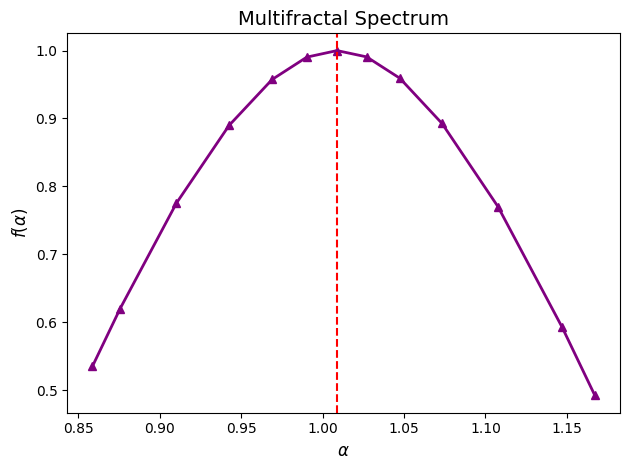

In [27]:
X = r[:, 0] # leave burn in
N = len(X)
s_min = 10
s_max = len(X) // 4
qs = np.arange(-6, 7,1) # reccomended in lit for between -6 and 6
m= 1
steps = 40
mu_X = np.mean(X)
Y = np.cumsum(X - mu_X)
F_qs = list()
fitss1 = list()
fitss2 = list()

for q in qs: 

    F_q, ss, fits1, fits2, buffer = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)
    F_qs.append(F_q)
    
    if q == 2:
        
        fitss1.append(fits1)
        fitss2.append(fits2)
colors = plt.cm.Dark2(np.linspace(0, 1, len(qs)))

plt.figure(figsize = (8, 5))
for q_val, Fq, c in zip(qs, F_qs, colors):
    plt.plot((ss), np.log10(Fq), label=f'q={q_val}',  color = c, linewidth = 1.5)
plt.xscale('log')
plt.xlabel('S')
plt.ylabel(r'$\text{log}(F_q)$')
plt.title(r'MF-DFA for various $q$')
plt.legend(fontsize = "large")
plt.tight_layout()
plt.show()
plt.figure(figsize = (12, 6))


generalised_H = np.zeros(len(qs))

for i in range(len(F_qs)): 

    generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)
plt.plot(qs, generalised_H, linestyle='-', marker='o', markersize=6, linewidth=2, color='b')
plt.xlabel(r'$q$', fontsize=12)
plt.ylabel(r'Generalised Hurst exponent $H(q)$', fontsize=12)
plt.title(r'Generalised Hurst Exponent vs. Moment Order $q$', fontsize=14)
plt.tight_layout()
plt.show()

tao_q, alpha_q, f_alpha = get_mf_spectrum(generalised_H, qs)
f_alpha_max_idx = np.argmax(f_alpha)

plt.plot(alpha_q, f_alpha, marker='^', markersize=6, linewidth=2, color='purple')
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'$f(\alpha)$', fontsize=12)
plt.title(r'Multifractal Spectrum', fontsize=14)
plt.axvline(x=alpha_q[f_alpha_max_idx], color='red', linestyle='--', label='max f_alpha')
plt.tight_layout()
plt.show()